In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('covid_19.csv')

display(df.head())
display(df.info())

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    object 
 1   continent   236 non-null    object 
 2   population  229 non-null    float64
 3   day         238 non-null    object 
 4   time        238 non-null    object 
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 16.9+ KB


None

### Clean Data (Handle NaNs, Convert Dates)

In [5]:
df['Recovered'] = df['Recovered'].fillna(0)
df['Deaths'] = df['Deaths'].fillna(0)
df['Tests'] = df['Tests'].fillna(0)
df['continent'] = df['continent'].fillna('Other')

df['day'] = pd.to_datetime(df['day'])

aggregates = ['All', 'Europe', 'Asia', 'North-America', 'South-America', 'Africa', 'Oceania']
df_countries = df[~df['country'].isin(aggregates)].copy()

df_countries = df_countries.drop_duplicates()

print(f"Data cleaned! Total Countries Remaining: {len(df_countries)}")

Data cleaned! Total Countries Remaining: 231


### Top 5 Cases Visualization

C:\Users\donga\AppData\Local\Temp\ipykernel_15884\123221628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_cases, x='country', y='Cases', palette='Reds_r')


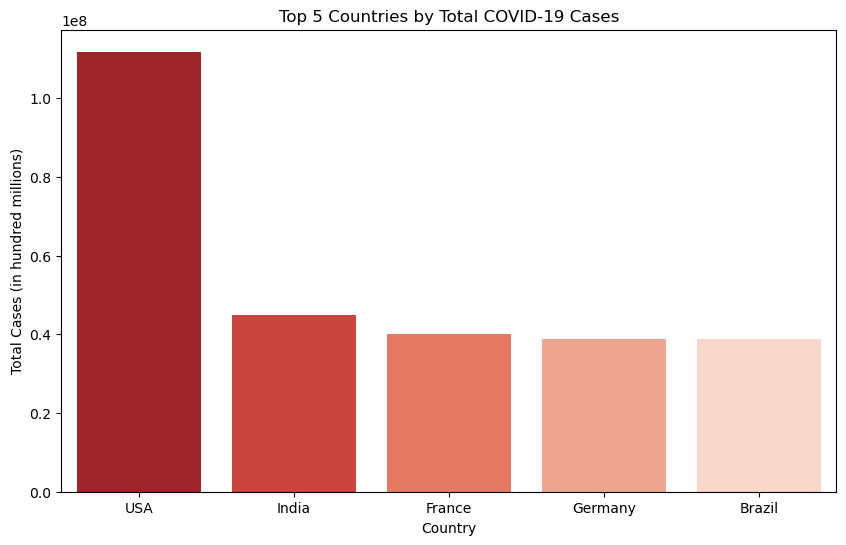

In [7]:
top_5_cases = df_countries.sort_values(by='Cases', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_cases, x='country', y='Cases', palette='Reds_r')
plt.title('Top 5 Countries by Total COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases (in hundred millions)')
plt.show()

### Descriptive Stats & Correlation Heatmap

,Cases,Recovered,Deaths,Tests
count,2.310000e+02,2.310000e+02,2.310000e+02,2.310000e+02
mean,3.050883e+06,2.426700e+06,3.034927e+04,3.041777e+07
std,1.002125e+07,9.196220e+06,1.092314e+05,1.154321e+08
min,9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.636600e+04,2.189500e+03,1.855000e+02,2.260585e+05
50%,2.068970e+05,5.894700e+04,1.974000e+03,1.690934e+06
75%,1.348198e+06,1.032544e+06,1.428700e+04,1.169128e+07
max,1.118201e+08,1.098144e+08,1.219487e+06,1.186852e+09


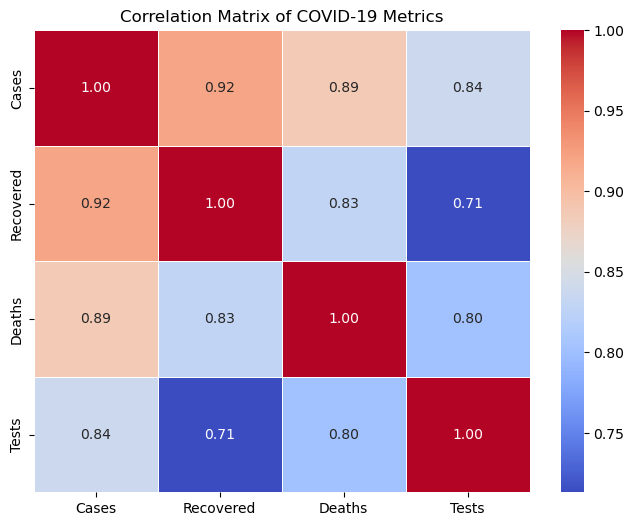

In [6]:
numerical_cols = ['Cases', 'Recovered', 'Deaths', 'Tests']
display(df_countries[numerical_cols].describe())

corr_matrix = df_countries[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of COVID-19 Metrics')
plt.show()

### Top 5 Mortality Visualization

C:\Users\donga\AppData\Local\Temp\ipykernel_15884\3511510884.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_mortality, x='country', y='Mortality_Rate', palette='magma')


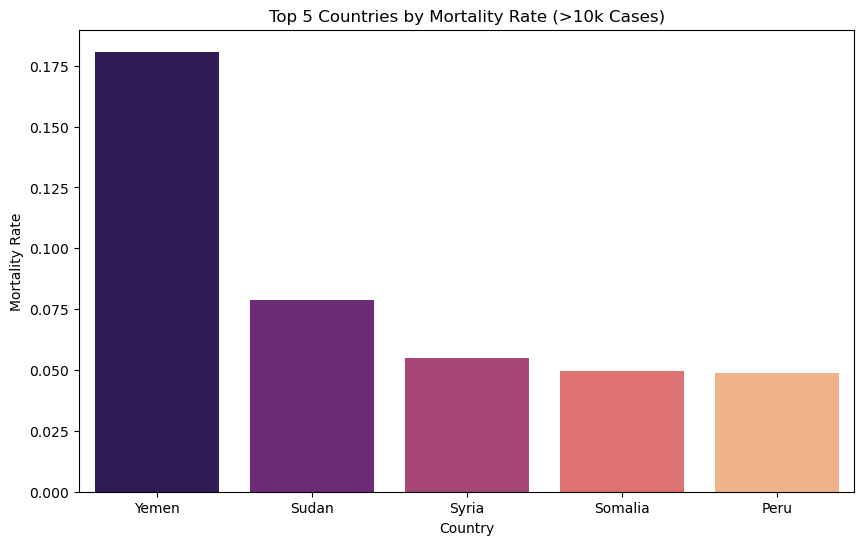

In [8]:
df_countries['Mortality_Rate'] = df_countries['Deaths'] / df_countries['Cases']
df_countries['Recovery_Rate'] = df_countries['Recovered'] / df_countries['Cases']

df_filtered = df_countries[df_countries['Cases'] > 10000].copy()

top_5_mortality = df_filtered.sort_values(by='Mortality_Rate', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_mortality, x='country', y='Mortality_Rate', palette='magma')
plt.title('Top 5 Countries by Mortality Rate (>10k Cases)')
plt.xlabel('Country')
plt.ylabel('Mortality Rate')
plt.show()

### Continent Aggregation & Visualization

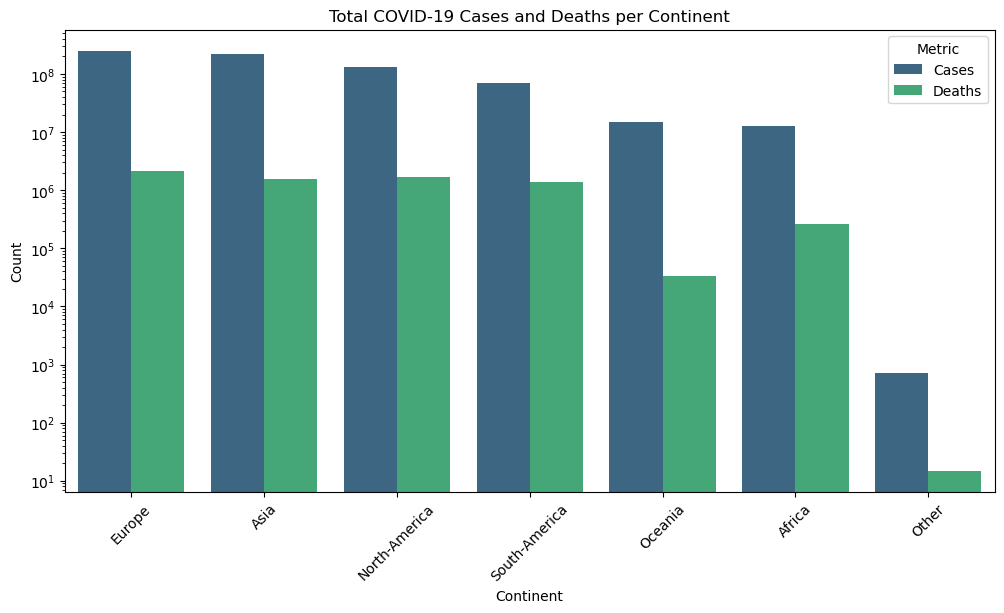

In [9]:
continent_stats = df_countries.groupby('continent')[['Cases', 'Deaths']].sum().reset_index()
continent_stats = continent_stats.sort_values(by='Cases', ascending=False)

continent_melted = continent_stats.melt(id_vars='continent', var_name='Metric', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=continent_melted, x='continent', y='Count', hue='Metric', palette='viridis')
plt.title('Total COVID-19 Cases and Deaths per Continent')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.yscale('log')
plt.xticks(rotation=45)
plt.show()

## 8. Conclusion and Final Insights

Based on the exploratory data analysis of the COVID-19 dataset, we can draw several key conclusions:
* **Global Disparity in Spread and Impact:** A small number of countries account for a massive percentage of global cases. Furthermore, grouping by continent reveals stark differences in both infection rates and total mortality, largely driven by population density and regional response strategies.
* **Testing as a Metric of Intervention:** Countries with high testing capacities generally show a more accurate (and often higher) case count. The scatter plot analysis indicates that robust testing is a critical factor in identifying and ultimately managing the virus's spread.
* **Mortality Rate Variations:** The mortality rate fluctuates significantly between countries. This suggests that the impact of the virus is highly dependent on localized factors, such as healthcare infrastructure readiness, average population age, and the timing of government interventions.